In [4]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

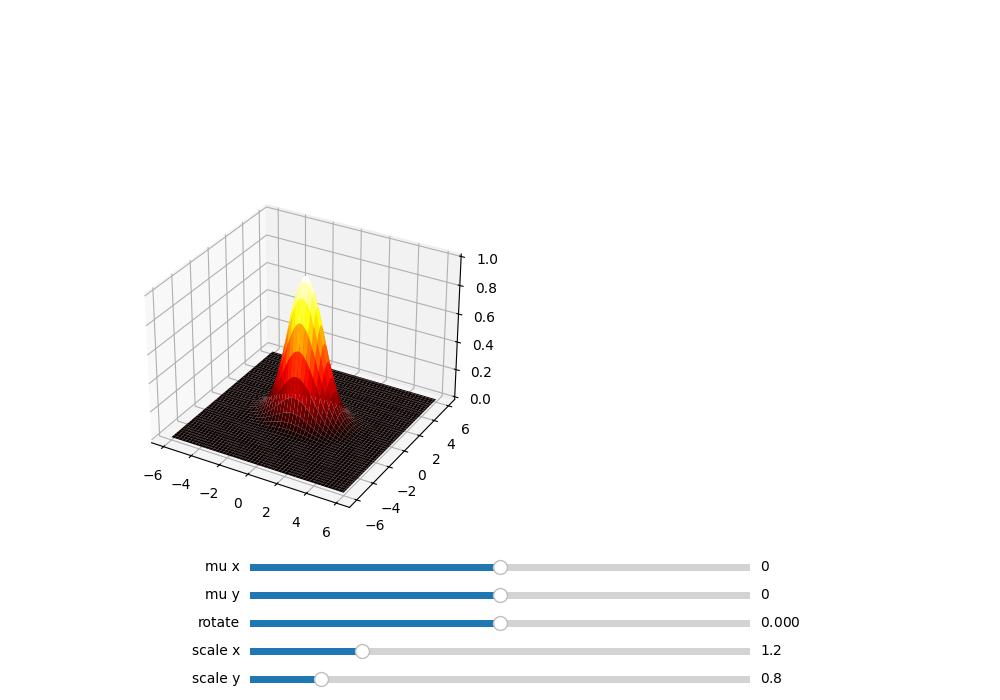

In [26]:
class gaussian_2d:
    def __init__(self):
        self.x = np.linspace(-6,6,100)
        self.y = np.linspace(-6,6,100)

        init_mu_x = 0.0
        init_mu_y = 0.0
        init_radian = 0.0
        init_scale_x = 1.2
        init_scale_y = 0.8

        self.fig = plt.figure(figsize=(10,7))
        self.ax = self.fig.add_subplot(121,projection='3d')

        self.mu_x_slider = Slider(plt.axes([0.25, 0.32-0.14, 0.5, 0.02]) ,'mu x', -6.0, 6.0, valinit=init_mu_x)
        self.mu_y_slider = Slider(plt.axes([0.25, 0.28-0.14, 0.5, 0.02]),'mu y', -6.0, 6.0, valinit=init_mu_y)
        self.radian_slider = Slider(plt.axes([0.25, 0.24-0.14, 0.5, 0.02]),'rotate', -3.141592, 3.141592, valinit=init_radian)
        self.scale_x_slider = Slider(plt.axes([0.25, 0.20-0.14, 0.5, 0.02]),'scale x', 0.1, 5, valinit=init_scale_x)
        self.scale_y_slider = Slider(plt.axes([0.25, 0.16-0.14, 0.5, 0.02]),'scale y', 0.1, 5, valinit=init_scale_y)

        self.x_, self.y_ = np.meshgrid(self.x, self.y)
        self.z_ =  self.calculate_gaussian(init_mu_x, init_mu_y, init_radian, init_scale_x, init_scale_y)
        self.ax.plot_surface(self.x_,self.y_, self.z_, cmap='hot')

        self.mu_x_slider.on_changed(self.update)
        self.mu_y_slider.on_changed(self.update)
        self.radian_slider.on_changed(self.update)
        self.scale_x_slider.on_changed(self.update)
        self.scale_y_slider.on_changed(self.update)

        plt.show() 

    def update(self, val):
        mu_x = self.mu_x_slider.val
        mu_y = self.mu_y_slider.val
        radian = self.radian_slider.val
        scale_x = self.scale_x_slider.val
        scale_y = self.scale_y_slider.val

        self.z_ =  self.calculate_gaussian(mu_x, mu_y, radian, scale_x, scale_y)
        self.ax.clear()
        self.ax.plot_surface(self.x_,self.y_,self.z_, cmap='hot')
        self.fig.canvas.draw_idle()

    def calculate_gaussian(self, mu_x, mu_y, radian, scale_x, scale_y):
        flat_x = self.x_.ravel() - mu_x
        flat_y = self.y_.ravel() - mu_y
        
        c = np.cos(radian)
        s = np .sin(radian)

        R = np.array([[c, -s], 
                      [s,c]])
        S = np.array([[scale_x , 0],
                      [0, scale_y]])
        sigma  = R @ S @ S.T @ R.T
        inv_sigma = np.linalg.inv(sigma)

        D = np.stack((flat_x, flat_y), axis=1)
        power = np.sum(D * (D @ inv_sigma), axis=1)
        
        return np.exp(-power/2).reshape(self.x_.shape)
    
g2 = gaussian_2d()


(65536, 2)


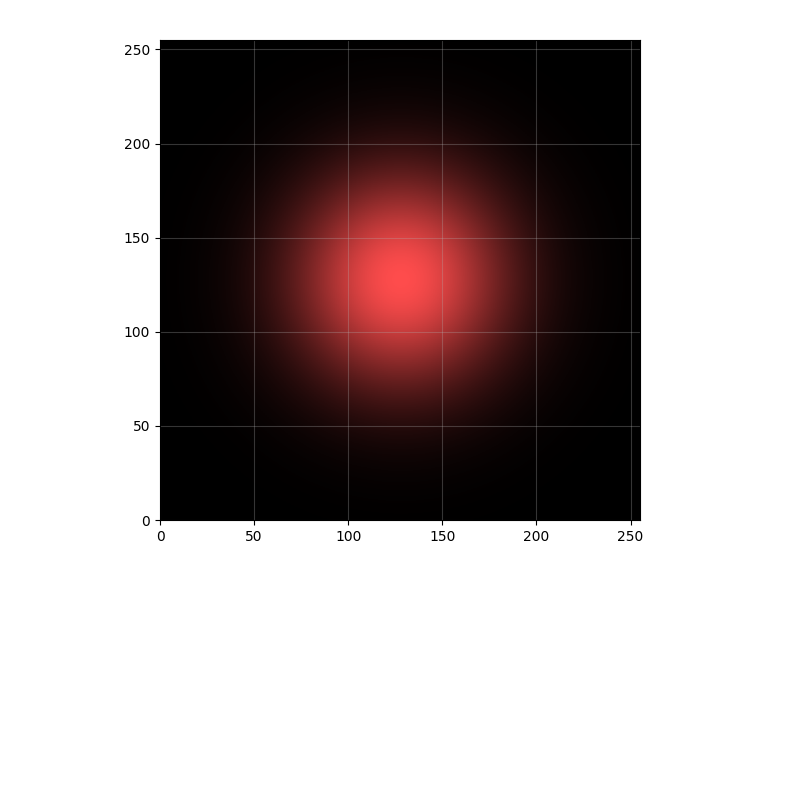

In [ ]:
width = 256
height = 256
color = (1.0, 0.3, 0.3)
ax_image = plt.axes([0.1, 0.35, 0.8,0.6])
ax_image.set_xlim(0,width-1)
ax_image.set_ylim(0,height-1)
ax_image.grid(True, alpha=0.3)

def gaussian_2d_image(x,y, mu_x, mu_y, sigma_x, sigma_y, rad):
    flat_x = x.ravel() - mu_x
    flat_y = y.ravel() - mu_y
    
    c, s = np.cos(rad), np.sin(rad)
    S = np.array([[sigma_x, 0], [0, sigma_y]])
    R = np.array([[c,-s],[s,c]])
    sigma = S@R@R.T@S.T
    inv_sigma = np.linalg.inv(sigma)

    X = np.stack([flat_x, flat_y], axis=1)
    print(X.shape)
    power = np.sum(-0.5 * X * (X@inv_sigma), axis=1)
    gaussian = np.exp(power)

    img = gaussian.reshape(height, width)
    image = np.stack([color[ch] * img for ch in range(3)], axis=2)

    return np.clip(image,0,1)

fig = plt.figure(figsize=(8,8))
fig.subplots_adjust(bottom=0.35)

max_x = (width / 2.0) - 0.5
max_y = (height / 2.0) - 0.5
x = np.arange(-max_x,max_x+1,1)
y = np.arange(-max_y,max_y+1,1)


X, Y = np.meshgrid(x,y)

sigma_x = 40
sigma_y = 40
degree = 20
rad = np.deg2rad(degree)

image = gaussian_2d_image(X,Y,0,0,sigma_x,sigma_y,rad)
img = ax_image.imshow(image , extent=[0,width, height, 0])

plt.show()

#ax_image.imshow()